### IID Uniform Sampling for Linear Region Count

#### Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

#### Code to generate iid uniform random sample:

In [2]:
def iid_uniform_sample(num_points,dimensions, lower_bounds, upper_bounds, rng):
    """Generates an iid uniform sample of points in a space of some dimension
    Args:
        num_points: the number of points to sample
        dimensions: the dimension of the space to sample from
        lower_bounds: 1D array of shape (dimensions), with the lower bounds of the sampling region
        upper_bounds: 1D array of shape (dimensions), with the upper bounds of the sampling region
        rng: a random number generator used to ensure reproducibility of the sample
    Returns:
        points: 2D array of shape (num_points,dimensions) representing all the points
    """

    points = np.zeros((num_points,dimensions))
    for d in range(dimensions):
        sample = rng.uniform(lower_bounds[d],upper_bounds[d],num_points)
        points[:,d] = sample
    return points

Test function and display resulting sample:

In [3]:
num_points = 10000
dimensions = 2
lower_bounds = np.full(dimensions,0)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=1)
points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)

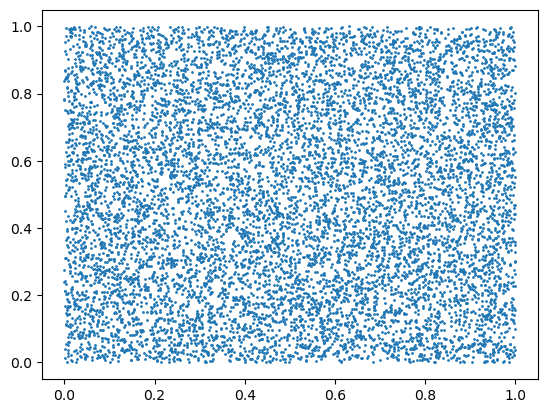

In [4]:
plt.scatter(points[:,0],points[:,1],s=1)

#### Code to set up MLP

Define class for a flexible MLP. It should allow the user to specify:
1. Dimension of the input space
2. Number of hidden neurons in each layer of the network (and therefore number of hidden layers)
3. Whether to use custom (user-provided) initial weights or to set them using Kaiming Normal Distribution (He initialisation)

In [5]:
class MLP(torch.nn.Module):
    def __init__(self,dimensions,neurons_per_hidden,custom_weights=None):
        """Set up the neural network model according to the specification given by parameters
        Args:
            dimensions: number of input dimensions
            neurons_per_hidden: 1D array or list containing widths of each layer
            custom_weights: None if Kaiming normal initialisation is to be used, otherwise a list of 2D torch tensors,
                            representing weight matrices to be used between each adjacent pair of layers
        """
        super().__init__()

        # Create a PyTorch list to store the layers and store the number of neurons per layer
        self.layers = torch.nn.ModuleList()
        self.architecture = neurons_per_hidden

        # Create first hidden layer using dimensions parameter
        hidden1 = torch.nn.Linear(dimensions, neurons_per_hidden[0], bias=False)
        self.layers.append(hidden1)
        self.layers.append(torch.nn.ReLU())
        
        # Create the remaining hidden layers
        for i in range(len(neurons_per_hidden)-1):
            hidden = torch.nn.Linear(neurons_per_hidden[i], neurons_per_hidden[i+1], bias=False)
            self.layers.append(hidden)
            self.layers.append(torch.nn.ReLU())

        # Set initial weights for all layers using user-input or Kaiming normal initialisation
        if custom_weights:
            with torch.no_grad():
                for i in range(len(self.layers)):
                    if isinstance(self.layers[i],torch.nn.Linear):
                        self.layers[i].weight.copy_(custom_weights[i])
        else:
            generator = torch.Generator()
            generator.manual_seed(1)
            self.apply(lambda m: self.init_weights(m,generator))
            

    def init_weights(self, module, generator):
        """Initialise weights according to Kaiming normal distribution
        Args:
            module: the layer to be initialised
            generator: sets a random seed to ensure reproducibility of initial weights
        """
        if isinstance(module, torch.nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity="relu",generator=generator)

    
    def forward(self,x):
        """Forward pass through the network to get the activations of each layer for a batch of data
        Args:
            x: a batch of inputs - 2D array of inputs of shape (batch size, input dimension)
        Returns:
            activations: the activations of each neuron in each layer of the network,
                         as a 2D array of shape: (batch size, total number of neurons)
        """
        x = x.float()
        for layer in self.layers:
            x = layer(x)
            # The layers are Linear, ReLU, Linear, ReLU, etc. Store activations after linear layers
            if isinstance(layer,torch.nn.Linear):
                try:
                    activations = np.concatenate((activations,x.detach().numpy()),axis=1)
                # If we have the first layer, initialise the activations array
                except:
                    activations = x.detach().numpy()
        return activations

#### Code to count activation patterns/linear regions:

Create custom PyTorch dataset to process a batch of input points:

In [6]:
class SampleDataset(torch.utils.data.Dataset):
    """Custom dataset designed to store samples to be used in linear region counting"""

    def __init__(self, points):
        # self.points = array of samples of shape (num_points,input dimension)
        self.points = points
        
    def __len__(self):
        return points.shape[0]

    def __getitem__(self,index):
        input = points[index,:]
        return input

Function to get numbers of unique linear regions after $N$ samples, $U(N)$:

In [7]:
def region_count(sample_data_loader,model):
    """Count the number of unique linear regions in the input space of a MLP using
    random sample of points from that input space

    Args:
        sample_data_loader: the data loader used to process the input data in batches
        model: the neural network model we are analysing
    Returns:
        unique_counts: a list of the number of regions found after each new sample
        all_patterns: all the unique patterns that have been found
    """

    # Store unique activation patterns in a set for constant lookup time
    all_patterns = set()
    unique_counts = []

    for inputs in sample_data_loader:

        inputs = inputs.float()
        activations = model(inputs)

        # For each example in the batch
        for i in range(activations.shape[0]):

            # Get the activation pattern from the activation values
            example_values = activations[i,:]
            activation_pattern = ""
            for value in example_values:
                if value > 0:
                    activation_pattern += "1"
                else:
                    activation_pattern += "0"

            # Determine whether the activation pattern has been seen before, and update appropriately
            if activation_pattern in all_patterns:
                unique_counts.append(unique_counts[-1])
            else:
                if len(all_patterns)==0:
                    unique_counts.append(1)
                else:
                    unique_counts.append(unique_counts[-1]+1)
                all_patterns.add(activation_pattern)
                
    return unique_counts,all_patterns

#### Test: run code on simple neural network from first presentation and verify output

Put all the functions together to estimate linear region count in a simple neural network with a 2D input, single hidden layer, 2 hidden neurons and specific weights:

In [8]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [2]
custom_weights = [torch.tensor([[1.0,-1.0],[1.0,1.0]])]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
rng = np.random.default_rng(seed=1)

model = MLP(dimensions,neurons_per_hidden,custom_weights)
points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)
sample_dataset = SampleDataset(points)
sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=64, shuffle=False)
unique_counts, all_patterns = region_count(sample_data_loader,model)

Plot the number of linear regions found in terms of the number of samples:

Text(0, 0.5, 'U(N)')

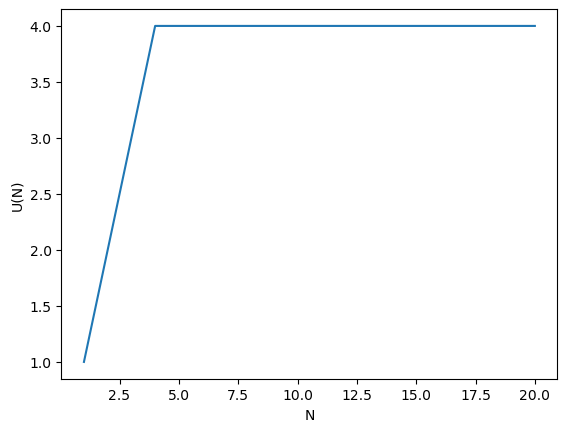

In [9]:
y = unique_counts[0:20]
x = np.arange(1,len(y)+1)
plt.plot(x,y)
plt.xlabel("N")
plt.ylabel("U(N)")

This saturates after 4 unique linear regions, which is the number that we find by doing exact calculations - this suggests that the code is working properly.

#### Experiment to test variance of sampling

Consider a neural network with 5 hidden layers and 20 hidden neurons per layer. We will repeat the experiment to count numbers of linear regions 30 times, taking a new set of random samples each time, and calculate the variance after taking each number of samples.

In [10]:
num_points = 10000
dimensions = 2
neurons_per_hidden = [20,20,20,20,20]
lower_bounds = np.full(dimensions,-1)
upper_bounds = np.full(dimensions,1)
model = MLP(dimensions,neurons_per_hidden)

num_runs = 30
total_unique_counts = np.empty((num_runs,num_points))

for i in range(num_runs):
    rng = np.random.default_rng(seed=i)
    points = iid_uniform_sample(num_points,dimensions,lower_bounds,upper_bounds,rng)
    sample_dataset = SampleDataset(points)
    sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=64, shuffle=False)
    unique_counts, all_patterns = region_count(sample_data_loader,model)
    total_unique_counts[i,:] = unique_counts

Text(0, 0.5, 'Unique Linear Regions')

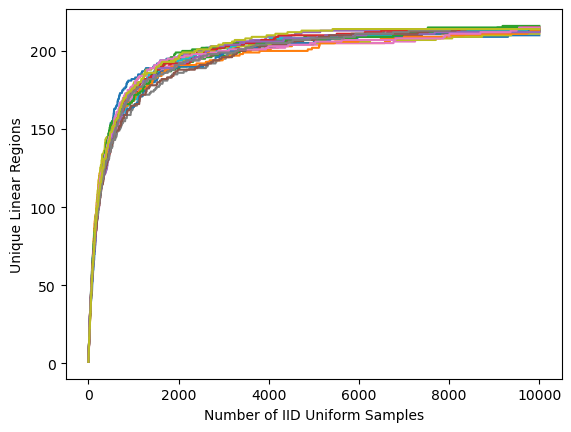

In [11]:
x = np.arange(1,total_unique_counts.shape[1]+1)
for i in range(1,20):
    plt.plot(x,total_unique_counts[i,:])
plt.xlabel("Number of IID Uniform Samples")
plt.ylabel("Unique Linear Regions")

In [12]:
variances = np.var(total_unique_counts, axis=0)

Text(0, 0.5, 'Variance in Linear Region Count')

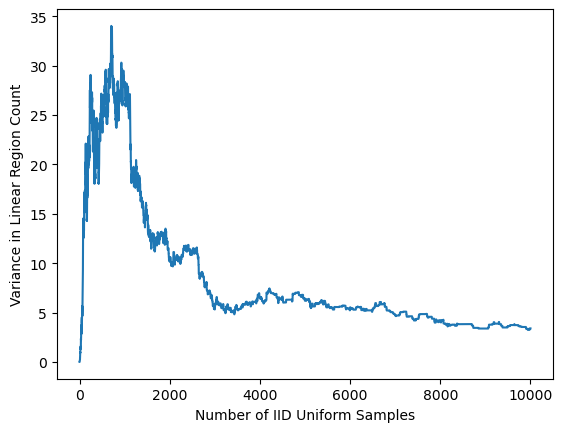

In [13]:
plt.plot(x,variances)
plt.xlabel("Number of IID Uniform Samples")
plt.ylabel("Variance in Linear Region Count")

This shows that the variance goes up rapidly at the start and comes down gradually as the number of samples increases, which is as expected.

#### Experiment to test increasing dimension

We will repeat the above experiment, except we will also change the input dimension. We will look at how the maximum variance and mean variance change as the input dimension is increased:

In [25]:
num_points = 10000
neurons_per_hidden = [20,20,20,20,20]

dimensions = [2,3,4,5,6,7]
num_runs = 30
max_var = []
mean_var = []
samples_until_saturation = []

for i in range(len(dimensions)):

    lower_bounds = np.full(dimensions[i],-1)
    upper_bounds = np.full(dimensions[i],1)
    model = MLP(dimensions[i],neurons_per_hidden)

    total_unique_counts = np.empty((num_runs,num_points))
    
    for j in range(num_runs):
        rng = np.random.default_rng(seed=j)
        points = iid_uniform_sample(num_points,dimensions[i],lower_bounds,upper_bounds,rng)
        sample_dataset = SampleDataset(points)
        sample_data_loader = torch.utils.data.DataLoader(sample_dataset, batch_size=64, shuffle=False)
        unique_counts, all_patterns = region_count(sample_data_loader,model)
        total_unique_counts[j,:] = unique_counts

    # Calculate the maximum variance obtained across the entire run 
    variances = np.var(total_unique_counts,axis=0)
    max_var.append(max(variances))
    mean_var.append(np.mean(variances))

Text(0, 0.5, 'Maximum Variance')

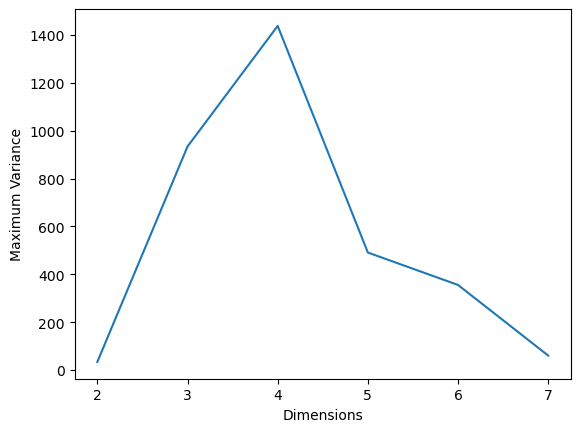

In [29]:
plt.plot(dimensions,max_var)
plt.xlabel("Dimensions")
plt.ylabel("Maximum Variance")

Text(0, 0.5, 'Mean Variance')

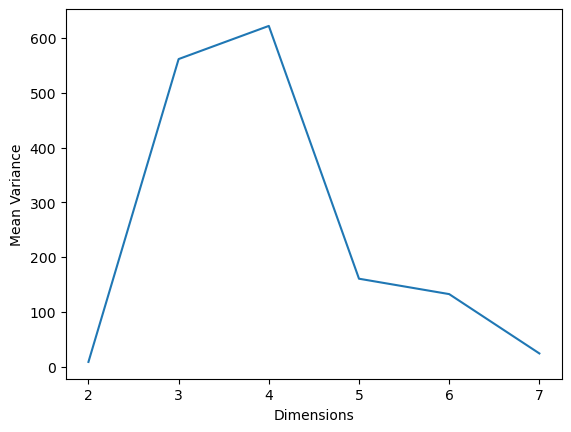

In [30]:
plt.plot(dimensions,mean_var)
plt.xlabel("Dimensions")
plt.ylabel("Mean Variance")